# Minimal Workflow Demonstration

In [1]:
import superstats as sup
import pandas as pd

INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:bayesflow:Using backend 'jax'
E0716 22:08:29.650209 2042276 cuda_executor.cc:1182] [0] Failed to allocate device memory of 17.64GiB (18939379712 bytes): RESOURCE_EXHAUSTED: : CUDA_ERROR_OUT_OF_MEMORY: out of memory


## Specify an Observation Model

In [2]:
obs_model = sup.simulation.cognitive.sample_ddm

## Specify a Joint Prior

Each model parameter prior can be specified via the following options:
- A `Transition` $\rightarrow$ `local_param` (time-varying, estimated)
- A `Prior` $\rightarrow$ `shared_param` (time-invariant, estimated)
- A `scalar` $\rightarrow$ `fixed_param` (time-varying, not estimated)

In [3]:
joint_prior = sup.prior.JointPrior(
    v = sup.transition.RandomWalk(
        bounds=(-6, 6),
    ),
    a = sup.transition.RandomWalk(
        bounds=(0.2, 4)
    ),
    tau = sup.prior.Prior("halfnormal", scale=0.5),
    bias = 0.5
)

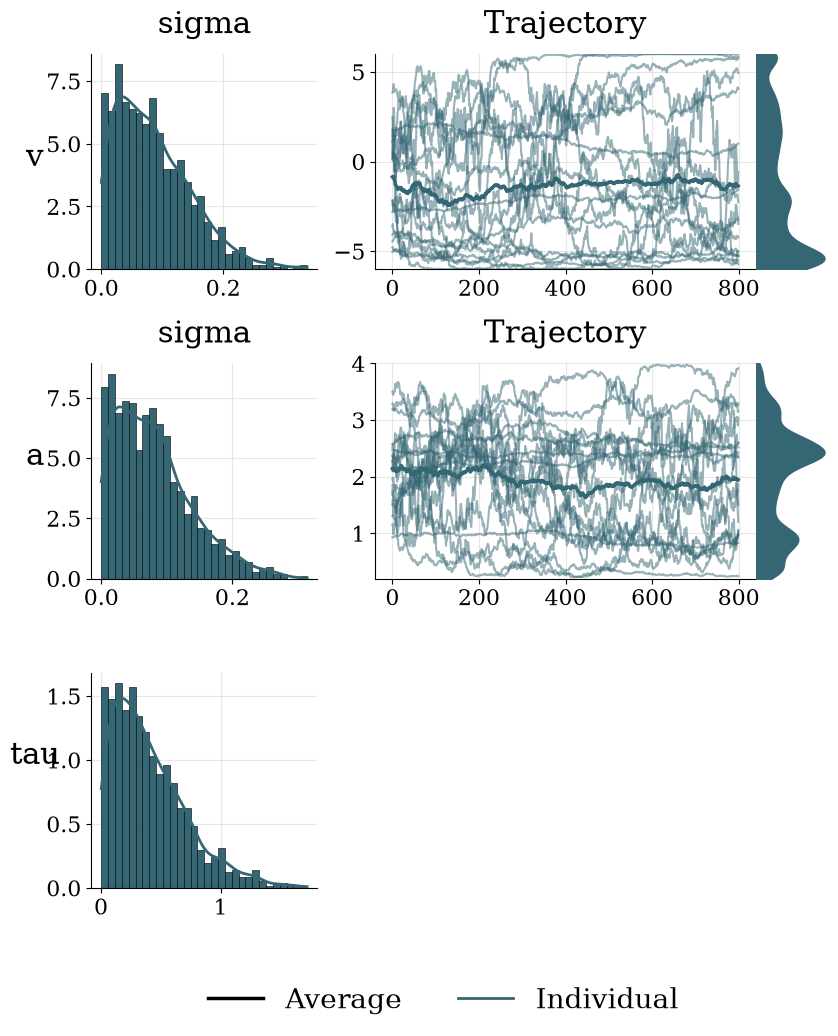

In [4]:
fig = joint_prior.plot_joint_prior(
    num_steps=800,
    num_draws=1000,
    num_trajectories=20
)

## Specify a Generative Model

In [5]:
generative_model = sup.simulation.GenerativeModel(
    prior=joint_prior,
    model=obs_model,
)

In [6]:
sim_data = generative_model.sample(batch_size=10, num_steps=800)

In [7]:
print(
    "Dict keys: ", sim_data.keys(), "\n",
    "Shape of response_time: ", sim_data["response_time"].shape, "\n",
    "Shape of a time-varying param: ", sim_data["v"].shape, "\n",
    "Shape of a time-invariant param: ", sim_data["v_sigma"].shape, "\n",
    sep=""
)

Dict keys: dict_keys(['response_time', 'choice', 'time_steps', 'v', 'a', 'v_sigma', 'a_sigma', 'tau'])
Shape of response_time: (10, 800)
Shape of a time-varying param: (10, 800, 1)
Shape of a time-invariant param: (10, 1)



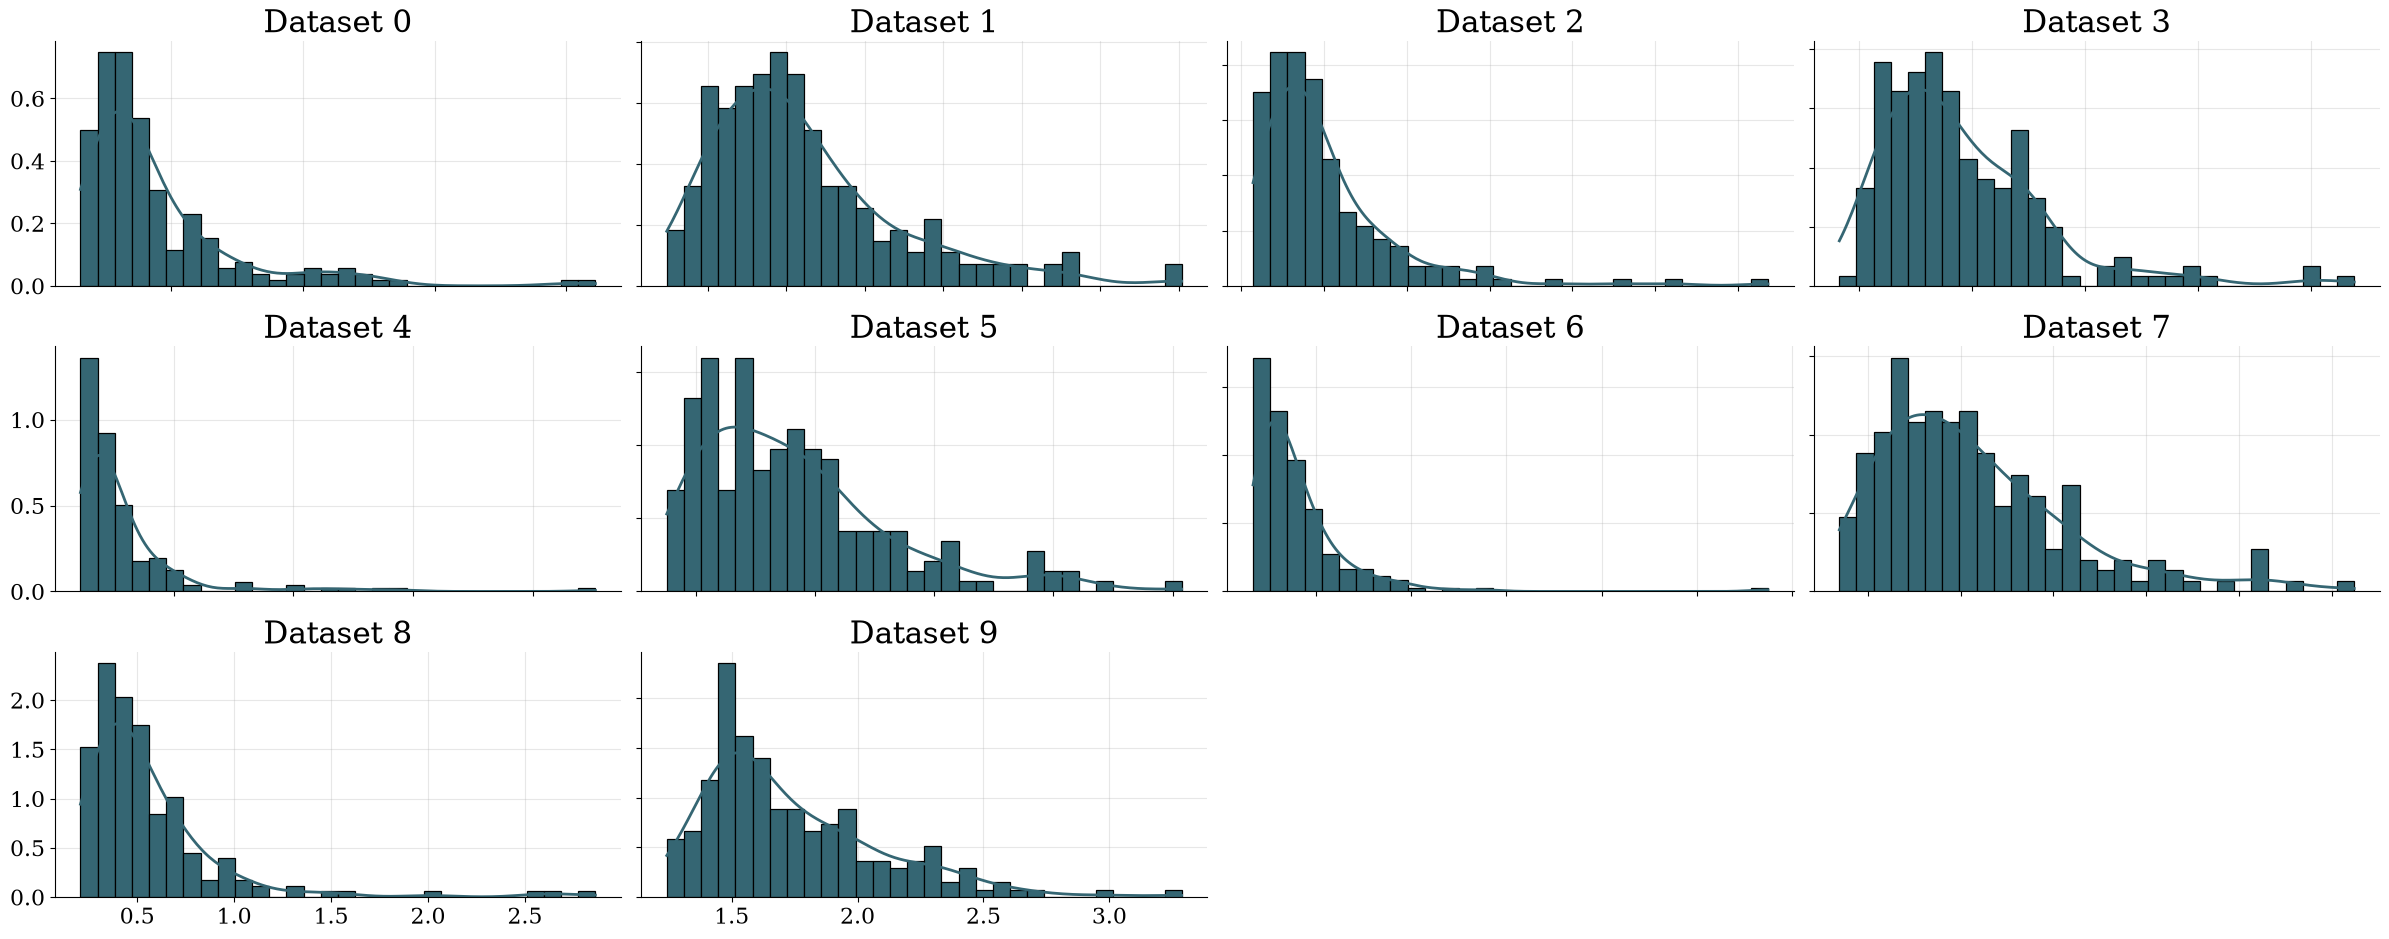

In [8]:
fig = generative_model.plot_push_forward(
    num_sim=10,
    num_steps=200,
    data_dim=0,
    kind="dist",
    aggregation=None,
    num_cols=4
)

## Set up amortized Bayesian Workflow 

In [9]:
workflow = sup.workflow.Workflow(
    simulator=generative_model,
    checkpoint_filepath="checkpoints/minimal_demo"
)

Here, users can provide summary and inference networks. Default networks are used if nothing is provided.

## Approximator Training

### Offline Training

Use offline training for fast iteration of the model develop and verification cicle

In [10]:
train_data = workflow.simulator.sample(
    batch_size=30000,
    num_steps=800,
    tile_to_steps=True
)
test_data = workflow.simulator.sample(
    batch_size=100,
    num_steps=800,
    tile_to_steps=True
)

In [ ]:
history = workflow.fit_offline(
    data=train_data,
    validation_data=test_data,
    epochs=75,
    batch_size=32
)

INFO:bayesflow:Fitting on dataset instance of OfflineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/75
170/938 ━━━━━━━━━━━━━━━━━━━━ 1:25 112ms/step - loss: 6.0702

In [ ]:
fig = workflow.plot_history(history)

### Online Training

Use online training for final maximal performance

In [ ]:
history = workflow.fit_online(
    num_steps=800,
    epochs=50,
    num_batches_per_epoch=1000,
    batch_size=32
)

In [ ]:
fig = workflow.plot_history(history)

## Model Verification

Simulate some data for verification

In [ ]:
targets = workflow.simulator.sample(
    batch_size=1000,
    num_steps=800,
)

In [ ]:
estimates = workflow.sample(
    data=targets['data'],
    num_samples=500
)

### Time-varying Parameters

In [ ]:
fig = workflow.verify_time_varying(
    targets=targets,
    estimates=estimates
)

### Time-invariant Parameters

In [ ]:
fig_recovery, fig_calibration = workflow.verify_time_invariant(
    estimates=estimates,
    targets=targets
)

## Fit Empirical Data

The empirical data needs to be in same shape as simulated data, which means we need a `ndarray` with shape `(num_datasets, num_steps, data_dims)`.

In [3]:
df = pd.read_csv("data/data_color_discrimination.csv")
empiric_data = sup.utils.df_to_array(df, id_col="id", data_cols=("rt", "correct"))
empiric_data.shape

(14, 768, 2)

In [ ]:
samples = workflow.sample(
    data=empiric_data,
    num_samples=500
)

## Posterior Re-simulation

## Posterior Estimates